In [1]:
#1
from sklearn.datasets import load_wine#importamos la libreria del dataset
import pandas as pd#importamos la libreria de pandas
wine=load_wine()#cargams el dataset
print(wine["feature_names"])
X = wine.data
Y = wine.target
df = pd.DataFrame(wine.data, columns=wine.feature_names)#guardamos el datset en un DataFRame
df["target"] = wine.target  


['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [2]:
#2
from sklearn.preprocessing import StandardScaler#libreria para StandarScaler que se utiliza para la normalización
from sklearn.decomposition import PCA#libreria para PCA
from sklearn.pipeline import Pipeline#libreria para pipeline
#creamos pipeline
pipe = Pipeline([
    ("transformer", StandardScaler()),   # normalización
    ("estimator", PCA(n_components=2))    # reducción a 2 dimensiones
])
print(pipe)
pipe.fit(df)#ajustams al set de datos
datos=pipe.transform(df)#aplicamos el pipeline

Pipeline(steps=[('transformer', StandardScaler()),
                ('estimator', PCA(n_components=2))])


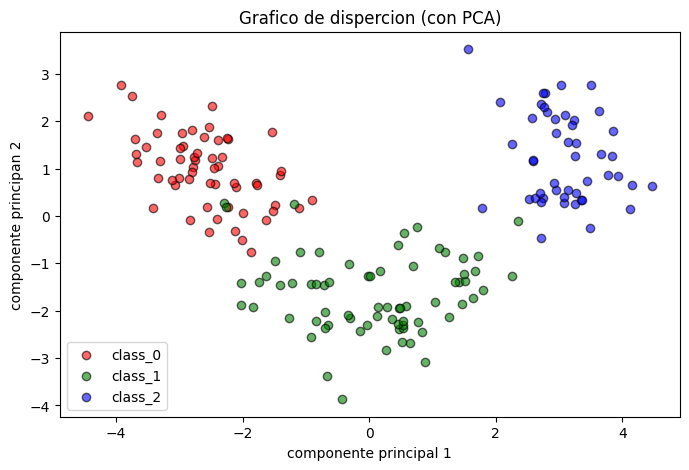

In [3]:
#3
import matplotlib.pyplot as plt#libreria para matplotlib
etiquetas=wine.target_names
colores=["red","green","blue"]
plt.figure(figsize=(8,5))
for i, color, label in zip([0,1,2], colores, etiquetas):#para cada clase aplicamos un color distinto
    plt.scatter(datos[Y == i, 0], datos[Y == i, 1], 
            c=color, label=label, alpha=0.6, edgecolors='k')
    
plt.title("Grafico de dispercion (con PCA)")
plt.xlabel("componente principal 1")
plt.ylabel("componente principan 2")
plt.legend()
plt.show()


In [4]:
#4
from sklearn.model_selection import train_test_split #libreria para separar los datos
X_train, X_test, Y_train, Y_test=train_test_split(datos,Y, test_size=0.3,  random_state=42, shuffle=True, stratify=None)

In [5]:
#5
from sklearn.cluster import KMeans#libreria modelo KMeans
from sklearn import metrics#libreria para adjusted_rand_score
# implementamos modelo
clusters=[2,3,4,5]
score=[]
for k in clusters: #for para probar con la distinta cantidad de clusters
    k_means = KMeans(n_clusters=k, max_iter=100)
    k_means.fit(X_train)
    prediccion = k_means.predict(X_test)
    evaluacion = metrics.adjusted_rand_score(Y_test, prediccion)
    print(f"Adjusted_rand_score para {k} clusters: {evaluacion}")



Adjusted_rand_score para 2 clusters: 0.3803623170436272
Adjusted_rand_score para 3 clusters: 1.0
Adjusted_rand_score para 4 clusters: 0.7722726292176156
Adjusted_rand_score para 5 clusters: 0.6806322729952187


In [6]:
#6
from sklearn.cluster import AffinityPropagation# libreria para el modelo
model=AffinityPropagation(preference=-55, damping=0.5, random_state=None)
af=model.fit(X_train)

#obtenemos numeros de clusters
cluster_center_indices=af.cluster_centers_indices_
labels=af.labels_
n_clusters_=len(cluster_center_indices)
print("Número estimado de clusters: %d" % n_clusters_)

#obtenemos porcentaje de acierto
predicciones=af.predict(X_test)
score=metrics.adjusted_rand_score(Y_test, predicciones)
print("Porcentaje de acierto:", score*100, "%")

Número estimado de clusters: 3
Porcentaje de acierto: 100.0 %


# COMENTARIO
A la hora de aplicar el modelo de Affinity Propagation se utilizó el parámetro de preference para llegar a un resultado de score mayor a 90%. En este caso se aplicó en la diagonal principal el valor de –55 haciendo que el modelo se incline por un numero de clúster chico. De esta manera aplicando este hiperparametro el modelo llego a la cantidad de clúster de los subgrupos conocidos del data set que es 3 y un score de 100%. 

Esta preference fue aplicada debido a que, sin ella, por defecto el modelo llena las celdas de la diagonal principal de la matriz de similitud con el valor de la mediana de las similitudes, la cantidad de clústeres a la que llegaba era 7 y el score de 52,8% siendo este valor bastante alejado del objetivo ya que encontró subestructuras (es decir que encontró otros subgrupos) que no coincidían con los de las etiquetas. 

Por otro lado, al aplicarlos valores de preference mayores a –55 la cantidad de clústeres encontrada no bajaba de 4 y el score no subía de 86.7%. 

También se solicitó aplicar a los datos de entrenamiento el algoritmo de KMeans, este llego a un score de 100% en el caso de 3 clústeres, lo mismo que el de Affinity Propagation. Se podría decir que en este caso (con este data set) KMeans fue más eficiente para encontrar el número de clústeres porque, aunque se probó con diferentes valores de K ocupo menos espacio de memoria y tiempo de cómputo que Afinnity Propagation . 